In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
def load_delta_data(base_path : str) -> list[pd.DataFrame]:
    files = [
        os.path.join(base_path, x) for x in list(sorted(
            os.listdir(base_path), key=lambda x: x.split('_')[0]
        ))
    ]
    ret = []
    for fp in files:
        with open(fp, 'r') as file:
            ret.append(pd.read_json(file, lines=True))
    return ret

id_dfs = load_delta_data('/ptmp/rfechner/out/exp12/id_data__qwen2.5_7b__gspo/val_jsonl/')
ood_dfs = load_delta_data('/ptmp/rfechner/out/exp12/ood_data__qwen2.5_7b__gspo/val_jsonl/')

In [3]:
def splice_id_data(dfs : list[pd.DataFrame]) -> list[pd.DataFrame]:
    """
        For each dataframe we only keep the rows for which checkpoint_global_step == step
    """
    ret = []
    for df in dfs:
        ret.append(
            df[df['checkpoint_global_step'] == df['step']].copy()
        )
    return ret

spliced = splice_id_data(id_dfs)

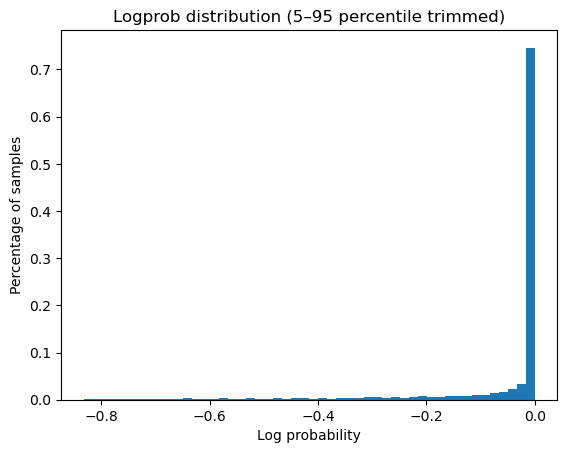

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df1 = spliced[0]
# I'd like to vizualize the preference shift: I'm assuming first checkpoint id rollouts will have larger variance in their logprobs.
all_logprobs = np.concatenate(df1['logprobs'])
lower, upper = np.percentile(all_logprobs, [5, 95])
filtered = all_logprobs[(all_logprobs > lower) & (all_logprobs < upper)]

weights = np.ones_like(filtered) / filtered.size

plt.hist(filtered, bins=50, weights=weights)
plt.ylabel("Percentage of samples")
plt.xlabel("Log probability")
plt.title("Logprob distribution (5–95 percentile trimmed)")
plt.show()

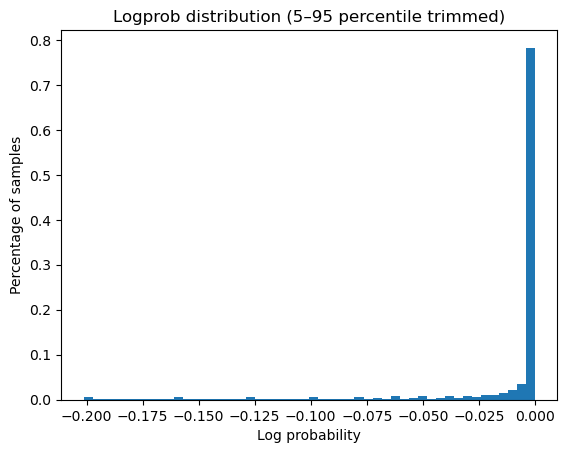

In [101]:
df1 = spliced[-1]

# I'd like to vizualize the preference shift: I'm assuming first checkpoint id rollouts will have larger variance in their logprobs.
all_logprobs = np.concat([np.array(x) for x in df1['logprobs']])
lower, upper = np.percentile(all_logprobs, [5, 95])
filtered = all_logprobs[(all_logprobs > lower) & (all_logprobs < upper)]

weights = np.ones_like(filtered) / filtered.size

plt.hist(filtered, bins=50, weights=weights)
plt.ylabel("Percentage of samples")
plt.xlabel("Log probability")
plt.title("Logprob distribution (5–95 percentile trimmed)")
plt.show()

In [56]:
df = spliced[-1]
grouped = df.groupby('uid', sort=False)
groups = list(grouped.groups.keys())
g1 = grouped.get_group(groups[0])
g1

,batch_index,logprobs,entropy,checkpoint_global_step,behaviour_type,step,uid
11974,187,"[-0.0098876953125, -0.0830078125, -0.4375, -0....","[0.06396484375, 0.30078125, 0.69921875, 0.0708...",80,anchor,80,1587
11975,187,"[-0.0098876953125, -0.0830078125, -0.4375, -0....","[0.06396484375, 0.30078125, 0.69921875, 0.0708...",80,anchor,80,1587
11976,187,"[-0.0098876953125, -0.0830078125, -1.0625, -0....","[0.06396484375, 0.30078125, 0.69921875, 0.0071...",80,anchor,80,1587
11977,187,"[-0.0098876953125, -0.0830078125, -0.4375, -0....","[0.06396484375, 0.30078125, 0.69921875, 0.0708...",80,anchor,80,1587
11978,187,"[-0.0098876953125, -0.0830078125, -0.4375, -0....","[0.06396484375, 0.30078125, 0.69921875, 0.0708...",80,anchor,80,1587
11979,187,"[-0.0098876953125, -0.0830078125, -1.0625, -0....","[0.06396484375, 0.30078125, 0.69921875, 0.0071...",80,calculation_error,80,1587


In [62]:
m = np.zeros(shape=(len(g1), g1['logprobs'].apply(len).max()))
for i, g in enumerate(g1['logprobs']):
    m[i, :len(g)] = np.array(g)

In [64]:
m

array([[-9.88769531e-03, -8.30078125e-02, -4.37500000e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-9.88769531e-03, -8.30078125e-02, -4.37500000e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-9.88769531e-03, -8.30078125e-02, -1.06250000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-9.88769531e-03, -8.30078125e-02, -4.37500000e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-9.88769531e-03, -8.30078125e-02, -4.37500000e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-9.88769531e-03, -8.30078125e-02, -1.06250000e+00, ...,
        -1.19209290e-06, -8.70227814e-06, -6.31713867e-03]],
      shape=(6, 791))

In [68]:
m1 = m - m.mean(axis=1, keepdims=True)
m2 = m1[-1, :] - m1[:-1, :].mean(axis=0)


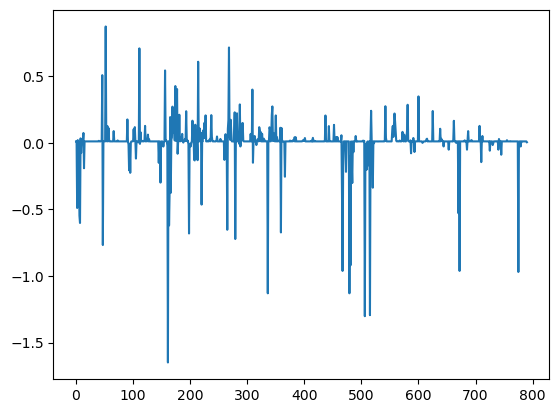

In [69]:
import matplotlib.pyplot as plt
plt.plot(m2)
plt.show()

In [70]:
with open('/u/rfechner/data/ariadne/id-deltas.jsonl', 'r') as jsonfile:
    raw = pd.read_json(jsonfile, lines=True)

In [71]:
raw.columns

Index(['prompt', 'behaviour_type', 'step', 'uid'], dtype='object')

In [72]:
df = raw[raw['step']==80]

In [73]:
grouped = df.groupby('uid', sort=False)
gkeys = list(grouped.groups.keys())
s1 = grouped.get_group(gkeys[12])

In [74]:
s1

,prompt,behaviour_type,step,uid
12058,"[{'role': 'user', 'content': 'Find the smalles...",anchor,80,1599
12059,"[{'role': 'user', 'content': 'Find the smalles...",anchor,80,1599
12060,"[{'role': 'user', 'content': 'Find the smalles...",anchor,80,1599
12061,"[{'role': 'user', 'content': 'Find the smalles...",anchor,80,1599
12062,"[{'role': 'user', 'content': 'Find the smalles...",anchor,80,1599
12063,"[{'role': 'user', 'content': 'Find the smalles...",calculation_error,80,1599
12064,"[{'role': 'user', 'content': 'Find the smalles...",calculation_error,80,1599
12065,"[{'role': 'user', 'content': 'Find the smalles...",calculation_error,80,1599


In [75]:
s1.iloc[0]['prompt']

[{'role': 'user',
  'content': "Find the smallest positive real number $C$ for which\n\\[\\left\\| \\begin{pmatrix} 2 & 3 \\\\ 0 & -2 \\end{pmatrix} \\bold{v} \\right\\| \\le C \\|\\bold{v}\\|\\]for all two-dimensional vectors $\\bold{v}.$\n\nNote that for a two-dimensional vector $\\mathbf{a},$ $\\|\\mathbf{a}\\|$ is the magnitude of $\\mathbf{a}.$ Let's think step by step and output the final answer within \\boxed{}."},
 {'role': 'assistant',
  'content': "To find the smallest positive real number \\( C \\) such that\n\\[\n\\left\\| \\begin{pmatrix} 2 & 3 \\\\ 0 & -2 \\end{pmatrix} \\bold{v} \\right\\| \\le C \\|\\bold{v}\\|\n\\]\nfor all two-dimensional vectors \\(\\bold{v}\\), we need to determine the operator norm of the matrix \\( A = \\begin{pmatrix} 2 & 3 \\\\ 0 & -2 \\end{pmatrix} \\).\n\nThe operator norm (induced 2-norm) of a matrix \\( A \\) is given by\n\\[\n\\|A\\| = \\max_{\\|\\mathbf{v}\\| = 1} \\|A\\mathbf{v}\\|.\n\\]\nThis is equivalent to the square root of the large

In [76]:
s1.iloc[-1]['prompt']

[{'role': 'user',
  'content': "Find the smallest positive real number $C$ for which\n\\[\\left\\| \\begin{pmatrix} 2 & 3 \\\\ 0 & -2 \\end{pmatrix} \\bold{v} \\right\\| \\le C \\|\\bold{v}\\|\\]for all two-dimensional vectors $\\bold{v}.$\n\nNote that for a two-dimensional vector $\\mathbf{a},$ $\\|\\mathbf{a}\\|$ is the magnitude of $\\mathbf{a}.$ Let's think step by step and output the final answer within \\boxed{}."},
 {'role': 'assistant',
  'content': "To find the smallest positive real number \\( C \\) such that\n\\[\n\\left\\| \\begin{pmatrix} 2 & 3 \\\\ 0 & -2 \\end{pmatrix} \\bold{v} \\right\\| \\le C \\|\\bold{v}\\|\n\\]\nfor all two-dimensional vectors \\(\\bold{v}\\), we need to determine the operator norm of the matrix \\( A = \\begin{pmatrix} 2 & 3 \\\\ 0 & -2 \\end{pmatrix} \\).\n\nThe operator norm (or induced norm) of a matrix \\( A \\) is defined as\n\\[\n\\|A\\| = \\max_{\\|\\bold{v}\\| = 1} \\|A \\bold{v}\\|.\n\\]\nThis is equivalent to the square root of the large